# Task 1 — Forecasting Across Heterogeneous Sensors

AI651 / CS434 / EE5108 · implementation notebook

Use the Task 1 handout in `main.pdf` for concepts and response instructions. This notebook
contains the implementations, checks, and outputs for each part.

The simulated setting is a 20 Hz four-station production line. Products A, B, and C set global
nominal pace ranges of 14--18, 21--27, and 28--36 samples; each operating run has one actual pace from
its product range. Stations 1--3 are established and station 4 is held out.

Write every assessed response in your report. Each part has its own simple rhythm:
inspect its **Outputs**, then write its named **Response**.

| Part | You implement | Outputs | Response |
| --- | --- | --- | --- |
| 0. The World and Forecasting Setup | — | — | — |
| 1. Context-Dependent Forecasting | Raw Attention forecaster | 1.1–1.3 | 1A, 1B |
| 2. Separate Slow Structure from Repetition | `SeriesDecomposition.forward` | 2.1–2.3 | 2 |
| 3. Mix by Temporal Delay | `aggregate_delays` (`delay_scores` is supplied) | 3.1–3.2 | 3 |
| 4. Compare Designs and Deploy | — | 4.1–4.3 | 4 |

Short-horizon vibration forecasts provide the expected near-term baseline for condition monitoring.
Deviations from that expected behavior can indicate abnormal operation.

**Every implementation is checked where you write it.** Each implementation has a clear contract
and an immediate check; the numerical components also include small worked examples. Checks test
values, shapes, and gradients and name the likely cause when they fail. Nothing is left for a
training run to discover.


## 0. The World and Forecasting Setup

**Physical line:** Station 1 → Station 2 → Station 3 → Station 4. Each station has one vibration
accelerometer sampled at 20 Hz. Stations 1–3 are established; Station 4 is held out from fitting
but still supplies its own 96-sample context at inference time.

| Product | Actual pace in each operating run |
| --- | --- |
| A | 14–18 samples per cycle |
| B | 21–27 samples per cycle |
| C | 28–36 samples per cycle |

Each reading combines a slow drift, a repeating vibration, and small noise. A forecast receives
`L=96` readings from one station and predicts `H=48` future readings. Windows never cross a product
changeover. Train is samples 0–9600, validation is 9600–12480, and final test is 12480–15360.
Anchoring and scaling are supplied and use established-station training data only.

### Environment setup

Use Python 3.11 or later. From the unzipped assignment directory:

```bash
python -m venv .venv
# Linux/macOS:
source .venv/bin/activate
# Windows PowerShell:
# .venv\Scripts\Activate.ps1
python -m pip install -r requirements.txt
jupyter lab
```

For CPU-only PyTorch, install it from its CPU wheel index before installing the remaining
requirements:

```bash
python -m pip install torch --index-url https://download.pytorch.org/whl/cpu
python -m pip install -r requirements.txt
```

Keep `harness/` and `requirements.txt` beside this notebook.

#### Important: The notebook starts with PA1_PRESET=smoke only to make implementation and debugging fast. All results used in your report must come from a fresh PA1_PRESET=full run. 

In [28]:
import os
import math
import sys
from pathlib import Path

for candidate in (Path("harness"), Path("PA 01/harness"), Path("../harness")):
    if candidate.is_dir():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise FileNotFoundError("Keep harness/ beside this notebook and start Jupyter there.")

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from IPython.display import display
import design_controls as design
import design_data as data
import design_diagnostics as figures
import design_reporting as report

os.environ["PA1_DEVICE"] = "cpu"
preset = os.environ.get("PA1_PRESET", "full")
seed = int(os.environ.get("PA1_SEED", "0"))
model_seed = int(os.environ.get("PA1_MODEL_SEED", str(seed)))
study = design.Study(preset, seed, model_seed=model_seed)
assert design.check_world(study.world)
print(f"preset={preset}; data seed={seed}; model seed={model_seed}; device={design.device}")
print(f"sampling rate={data.SAMPLING_RATE_HZ:g} Hz; products={', '.join(study.world.product_names)}")
print(f"product pace ranges={study.world.product_period_bands.tolist()} samples; "
      f"established stations={study.established.sum()}; held-out station=4")
print(f"eligible train/validation/test origins: "
      f"{len(study.region('train')['origins'])}/"
      f"{len(study.region('validation')['origins'])}/"
      f"{len(study.region('test')['origins'])}")



Four-station product-line world checks passed.
preset=full; data seed=0; model seed=0; device=cpu
sampling rate=20 Hz; products=Product A, Product B, Product C
product pace ranges=[[14.0, 18.0], [21.0, 27.0], [28.0, 36.0]] samples; established stations=3; held-out station=4
eligible train/validation/test origins: 650/105/105


## 1. Context-Dependent Forecasting

The handout ends Part 1 by wrapping Attention in an encoder and naming the result
**Raw Attention**: the forecaster every later section improves. Building it is your first
implementation, and it has to exist before any of Part 1's evidence can be produced.

Before the comparison, write the ordering you expect for **Response 1A**.

Produces **Outputs 1.1–1.3** → used in **Responses 1A and 1B**.


### Assemble the forecaster

At this point there is only one model: **Raw Attention**. It embeds the raw context, uses
Attention to mix positions, then predicts the next 48 readings.

Routine layers are complete. **You write the `RawAttentionForecaster.forward` assembly.**
Input `context` is `[B, L, 1]`; `self.embed` wants `[B, channels, L]` and returns `[B, d, L]`;
the encoder blocks use `[B, L, d]`; flatten that final representation before the forecast head
to return `[B, H]`.

The next cell immediately checks the output shape and gradient flow.


In [29]:
class DenseAttention(nn.Module):
    def __init__(self, d, heads):
        super().__init__()
        if d % heads:
            raise ValueError("width must be divisible by heads")
        self.heads = heads
        self.query, self.key, self.value = (nn.Linear(d, d) for _ in range(3))
        self.out = nn.Linear(d, d)
        self.last_attention = None

    def forward(self, x):                       # [B,L,d]
        batch, length, width = x.shape
        shape = (batch, length, self.heads, width // self.heads)
        q, k, v = (layer(x).view(shape).transpose(1, 2)
                   for layer in (self.query, self.key, self.value))  # [B,h,L,d_h]
        weights = (q @ k.transpose(-1, -2) / math.sqrt(q.shape[-1])).softmax(-1)
        self.last_attention = weights.detach()  # [B,h,L,L]
        mixed = (weights @ v).transpose(1, 2).reshape(batch, length, width)
        return self.out(mixed)                  # [B,L,d]

class RawAttentionBlock(nn.Module):
    def __init__(self, d, heads, dropout):
        super().__init__()
        self.mix = DenseAttention(d, heads)
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.feed_forward = nn.Sequential(
            nn.Linear(d, 2 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
    def forward(self, x):                       # [B,L,d]
        x = x + self.drop(self.mix(self.norm1(x)))
        return x + self.drop(self.feed_forward(self.norm2(x)))

class RawAttentionForecaster(nn.Module):
    def __init__(self, context=96, horizon=48, channels=1, d=64, heads=4, layers=2,
                 dropout=0.1):
        super().__init__()
        self.embed = nn.Conv1d(channels, d, 3, padding=1, padding_mode="circular", bias=False)
        self.position = nn.Parameter(torch.randn(1, context, d) * 0.02)
        self.blocks = nn.ModuleList([RawAttentionBlock(d, heads, dropout)
            for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.forecast_head = nn.Linear(context * d, horizon)

    def forward(self, context): 
        
        context = context.transpose(1, 2)  # [B,L,1] -> [B,1,L]
        context = self.embed(context)  # [B,1,L] -> [B,d,L]
        context = context.transpose(1, 2)  # [B,d,L] -> [B,L,d]
        context = context + self.position
        for block in self.blocks:
            context = block(context)
        context = self.norm(context)
        context = context.reshape(context.shape[0], -1)
        return self.forecast_head(context)
    
    @property
    def attention_layers(self):
        return [block.mix for block in self.blocks if isinstance(block.mix, DenseAttention)]



In [30]:
assert design.check_raw_attention_assembly(RawAttentionForecaster)
design.register_components(raw_forecaster_type=RawAttentionForecaster)


Raw-Attention assembly and gradient checks passed.


### Evidence

| Cell below | Output | Read it for |
| --- | --- | --- |
| fit Raw Attention, then compare four forecasters | 1.1 | Response 1A — then revise the ordering you wrote |
| the same station under two products | 1.2 | Response 1B |
| Attention behaviour across two contexts | 1.3 | Response 1B |

The three ridge forecasters are supplied; you implement nothing for them.


In [31]:
study.train("Raw Attention")
report.publish("1.1", report.comparison(
    study, ["Shared ridge", "Sensor-specific ridge", "Period-routed ridge", "Raw Attention"]))


Raw Attention: loaded raw-attention-full-data0-model0-26889516e400.pt (6000 steps, 4990.7s on cpu)
Output 1.1


,model,established stations RMSE (m/s²),established stations MSE (m/s²)²,"established stations, Product A RMSE","established stations, Product B RMSE","established stations, Product C RMSE",held-out station 4 RMSE (m/s²),held-out station 4 MSE (m/s²)²,"held-out station 4, Product A RMSE","held-out station 4, Product B RMSE","held-out station 4, Product C RMSE",parameters,fit seconds
0,Shared ridge,0.767,0.588,0.805,0.854,0.621,0.876,0.767,0.909,0.982,0.713,4608,0.007
1,Sensor-specific ridge,0.768,0.590,0.804,0.852,0.630,unavailable,unavailable,unavailable,unavailable,unavailable,13824,0.015
2,Period-routed ridge,0.166,0.028,0.181,0.164,0.152,0.173,0.03,0.184,0.182,0.15,59904,0.043
3,Raw Attention,0.431,0.186,0.388,0.482,0.418,0.612,0.374,0.647,0.58,0.607,368368,4990.703


Output 1.2


,station,product,actual period (samples),model,window RMSE (m/s²)
0,1,Product A,16.135,Shared ridge,0.779
1,1,Product A,16.135,Sensor-specific ridge,0.787
2,1,Product A,16.135,Period-routed ridge,0.232
3,1,Product A,16.135,Raw Attention,0.290
4,1,Product C,30.093,Shared ridge,0.448
5,1,Product C,30.093,Sensor-specific ridge,0.436
6,1,Product C,30.093,Period-routed ridge,0.150
7,1,Product C,30.093,Raw Attention,0.378


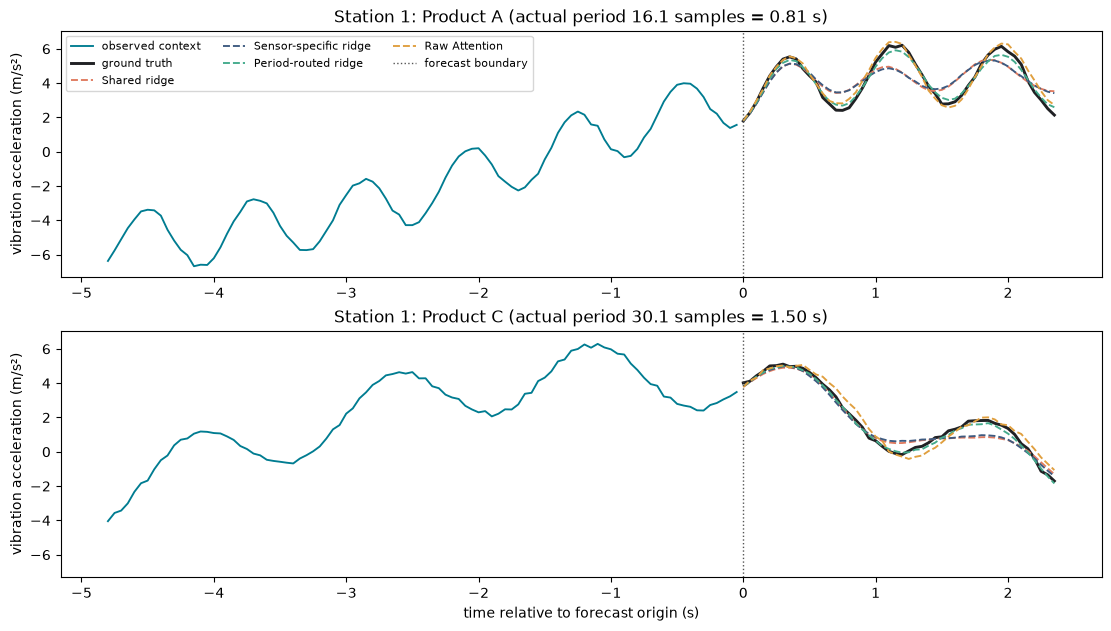

In [32]:
report.publish("1.2", figures.regime_forecasts(
    study, ["Shared ridge", "Sensor-specific ridge", "Period-routed ridge", "Raw Attention"]))


Output 1.3


,station,product,actual period (samples),mean |Attention weight difference|,max |Attention weight difference|
0,1,Product A,16.135,unavailable,unavailable
1,1,Product C,30.093,unavailable,unavailable
2,1,Product A vs Product C (difference),unavailable,0.011,0.425


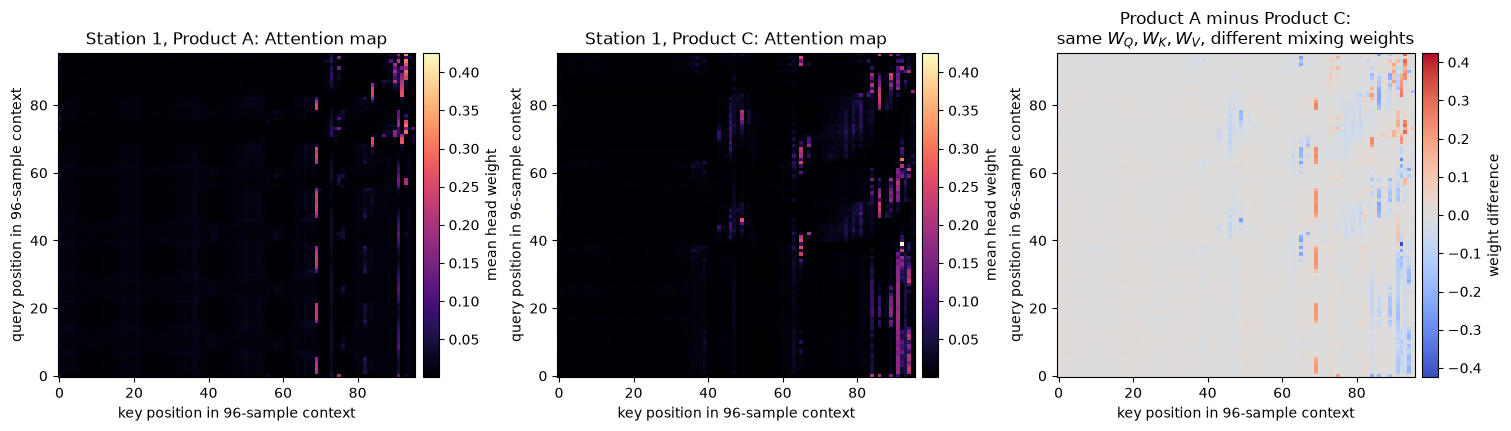

In [33]:
report.publish("1.3", figures.attention_behaviour(study))


## 2. Separate Slow Structure from Repetition

Switch 1. Across a 96-sample window the slow part of a reading is a smooth ramp, and it costs the
forecaster twice: the encoder spends representation on it, and it can hide the repeating
vibration. Splitting the context sends each stream to the part of the model suited to it, while
leaving the Attention mixer itself alone.

Implement the centered moving-average split below. Input and both outputs have shape
`(batch, time, channels)`; return `(remainder, trend)` **in that order**, so that
`remainder + trend == x` exactly.

The trap is the endpoints. For the first and last `kernel // 2` positions the averaging window
runs off the sequence: **replicate the nearest value there, rather than padding with zeros.**
Padding with zeros drags those positions toward zero, and it is the first thing the check
reports. The worked example below makes both endpoints visible before you run the check.

The supplied decomposed-Attention plumbing sends the remainder through Attention, the trend to a
linear head, and adds the two forecasts.

**Output 2.2 is an oracle diagnostic.** The synthetic generator's true period is available only
to score whether a width exposes the known repetition. It is not an input to the neural
forecaster, not a routing variable, and not information available in an ordinary deployment.

Produces **Outputs 2.1–2.3** → used in **Response 2**.

| Cell below | Output | Read it for |
| --- | --- | --- |
| trend/residual for several candidate widths | 2.1 | Response 2 |
| oracle primary-period recovery used to choose the width | 2.2 | Response 2 |
| decomposition ablation table and forecast shapes | 2.3 | Response 2 |


In [34]:
class SeriesDecomposition(nn.Module):
    def __init__(self, kernel):
        super().__init__()
        if kernel < 1 or kernel % 2 == 0:
            raise ValueError("kernel must be positive and odd")
        self.kernel = kernel

    def forward(self, x): 
        
        m = self.kernel // 2# x [B,L,C] -> (remainder, trend), each [B,L,C]
        x_t = x.transpose(1, 2) 
        x_t = F.pad(x_t, (m, m), mode='replicate')# [B,L,C] -> [B,C,L]
        trend = F.avg_pool1d(x_t, kernel_size=self.kernel, stride=1)
        trend = trend.transpose(1, 2)
        remainder = x - trend
        return remainder, trend


In [35]:
# Read this before running the check: kernel 3 on one short sequence, so the endpoint rule
# is visible. Interior: trend[1] = (1+2+3)/3 = 2. First position: the window needs x[-1], which
# is replicated from x[0], giving (1+1+2)/3 = 1.333 -- zero padding would give 1.0 instead.
example = torch.tensor([1., 2., 3., 10., 5.]).reshape(1, 5, 1)
remainder, trend = SeriesDecomposition(3)(example)
display(pd.DataFrame({
    "x": example.flatten(),
    "your trend": trend.flatten(),
    "expected trend": [4 / 3, 2., 5., 6., 20 / 3],
    "your remainder": remainder.flatten(),
}).round(4))


,x,your trend,expected trend,your remainder
0,1.0,1.3333,1.3333,-0.3333
1,2.0,2.0000,2.0000,0.0000
2,3.0,5.0000,5.0000,-2.0000
3,10.0,6.0000,6.0000,4.0000
4,5.0,6.6667,6.6667,-1.6667


Decomposition checks passed.
Decomposed-Attention assembly and gradient checks passed.
Output 2.1


,width,selected,residual std (m/s²),trend range (m/s²)
0,17,False,0.578,8.768
1,25,False,1.012,8.037
2,33,False,1.372,8.076
3,41,True,1.572,8.280


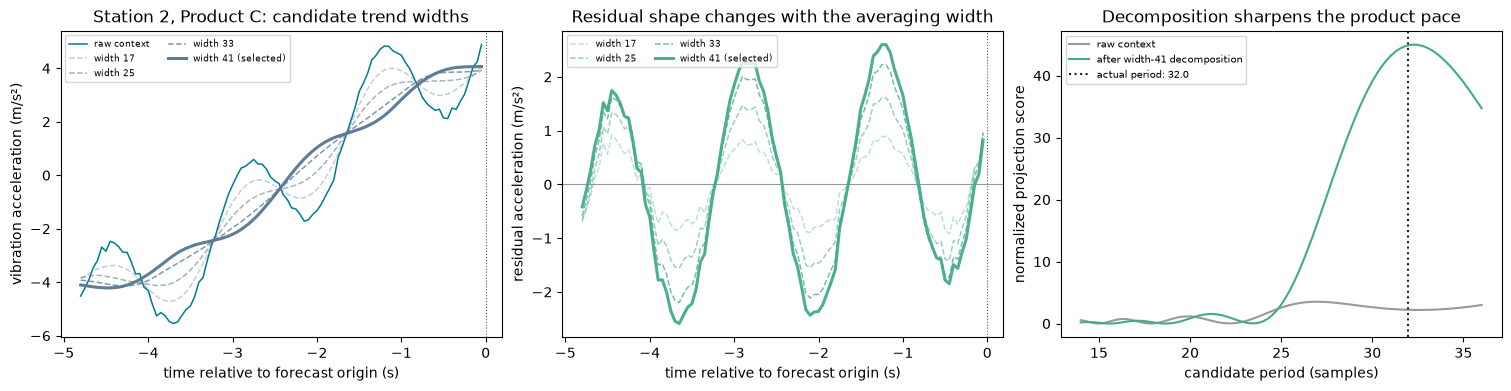

Output 2.2


,representation,oracle recovery within one sample,median absolute period error (samples),selected
0,raw,0.687,0.525,False
1,width 17,0.980,0.157,False
2,width 25,0.989,0.122,False
3,width 33,0.993,0.142,False
4,width 41,0.998,0.216,True


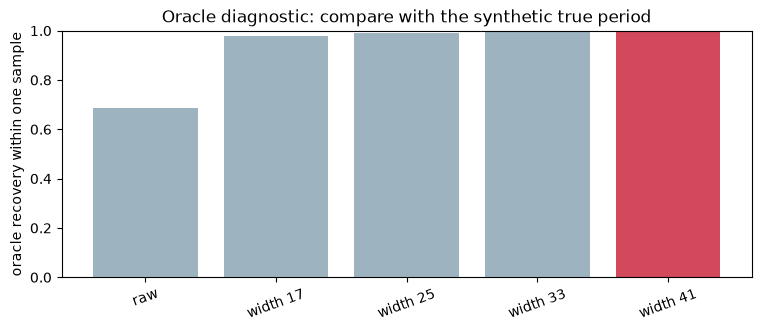

In [36]:
assert design.check_decomposition(SeriesDecomposition)
design.register_components(decomposition_type=SeriesDecomposition)

# Supplied Part 2 model: Attention mixes the remainder; a linear head forecasts the trend.
class DecompositionAttentionBlock(nn.Module):
    def __init__(self, d, heads, kernel, decomposition_type, dropout):
        super().__init__()
        self.mix = DenseAttention(d, heads)
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.feed_forward = nn.Sequential(
            nn.Linear(d, 2 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
        self.strip1, self.strip2 = decomposition_type(kernel), decomposition_type(kernel)

    def forward(self, x):                       # [B,L,d]
        x, _ = self.strip1(x + self.drop(self.mix(self.norm1(x))))
        x, _ = self.strip2(x + self.drop(self.feed_forward(self.norm2(x))))
        return x                               # [B,L,d]

class DecomposedAttentionForecaster(nn.Module):
    def __init__(self, context=96, horizon=48, channels=1, d=64, heads=4, layers=2,
                 kernel=25, dropout=0.1, decomposition_type=None):
        super().__init__()
        self.split = decomposition_type(kernel)
        self.trend_head = nn.Linear(context, horizon)
        self.embed = nn.Conv1d(channels, d, 3, padding=1, padding_mode="circular", bias=False)
        self.position = nn.Parameter(torch.randn(1, context, d) * 0.02)
        self.blocks = nn.ModuleList([DecompositionAttentionBlock(
            d, heads, kernel, decomposition_type, dropout) for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.forecast_head = nn.Linear(context * d, horizon)

    def forward(self, context):                 # [B,L,1] -> [B,H]
        seasonal, trend = self.split(context)
        encoded = self.embed(seasonal.transpose(1, 2)).transpose(1, 2) + self.position
        for block in self.blocks:
            encoded = block(encoded)
        seasonal_forecast = self.forecast_head(self.norm(encoded).flatten(1))
        return seasonal_forecast + self.trend_head(trend.squeeze(-1))

    @property
    def attention_layers(self):
        return [block.mix for block in self.blocks]

assert design.check_decomposed_attention_assembly(DecomposedAttentionForecaster, SeriesDecomposition)
design.register_components(decomposed_attention_forecaster_type=DecomposedAttentionForecaster)
report.publish("2.1", figures.filter_decomposition(study))
report.publish("2.2", figures.recurrence_recovery(study))


Attention + decomposition: loaded attention-decomposition-full-data0-model0-a7f72c88616e.pt (6000 steps, 7021.9s on cpu)
Output 2.3


,model,population,product,MSE,RMSE (m/s²),MAE (m/s²)
0,Raw Attention,established,Product A,0.150,0.388,0.293
1,Raw Attention,established,Product B,0.233,0.482,0.358
2,Raw Attention,established,Product C,0.175,0.418,0.306
3,Raw Attention,held-out,Product A,0.418,0.647,0.502
4,Raw Attention,held-out,Product B,0.336,0.580,0.439
5,Raw Attention,held-out,Product C,0.369,0.607,0.456
6,Attention + decomposition,established,Product A,0.070,0.264,0.204
7,Attention + decomposition,established,Product B,0.112,0.335,0.249
8,Attention + decomposition,established,Product C,0.080,0.283,0.212
9,Attention + decomposition,held-out,Product A,0.129,0.359,0.275


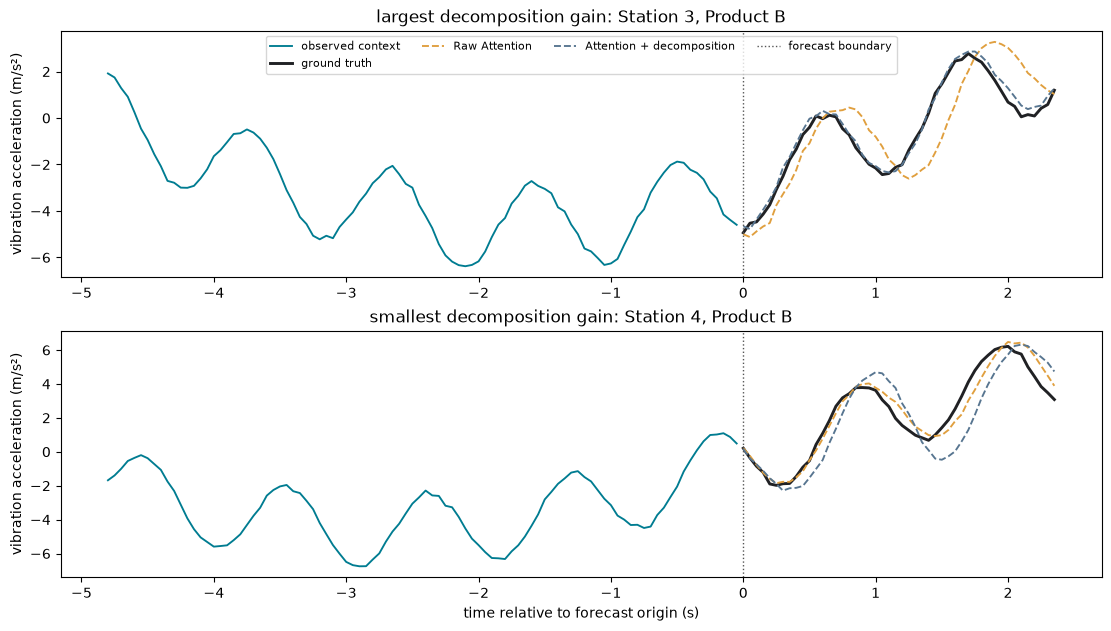

In [37]:
study.train("Attention + decomposition")
report.publish("2.3", figures.decomposition_ablation(study))


## 3. Mix by Temporal Delay

Switch 2 replaces the mixer rather than changing what the mixer is shown. Delay mixing scores
every delay, keeps the best few from the fixed band, sharpens them with a learned temperature,
and combines shifted copies of the context. Scoring every delay (`delay_scores`) is supplied;
you write the aggregation (`aggregate_delays`) that turns scored delays into a mixed sequence.

The mental model is: **score delays → select useful delays → shift values → combine them.**

Produces **Outputs 3.1–3.2** → used in **Response 3**.


### Delay scores (supplied)

`delay_scores(queries, keys)` takes tensors of shape `(batch, heads, features, time)` and returns
one score per delay, of shape `(batch, time)`. It is supplied below: it computes every delay's
score with two real forward FFTs and one inverse real FFT, in `O(L log L)` rather than the
`O(L^2)` a loop over delays would cost. You do not need to derive or reconstruct this procedure.

| Cell below | Output | Read it for |
| --- | --- | --- |
| the supplied scores on `[1, 3, 1, 3]`, against a direct calculation | 3.1 | Response 3 |


In [38]:
def delay_scores(queries, keys):
    # queries, keys: [B,heads,features,L] -> scores [B,L], one per delay tau = 0 .. L-1.
    # R(tau) = sum_t q[t] * k[(t - tau) mod L], centered in time, averaged over heads and
    # features. Supplied: an FFT computes every delay's score together in O(L log L).
    queries = queries - queries.mean(-1, keepdim=True)
    keys = keys - keys.mean(-1, keepdim=True)
    spectrum = torch.fft.rfft(queries, dim=-1) * torch.fft.rfft(keys, dim=-1).conj()
    return torch.fft.irfft(spectrum, n=queries.shape[-1], dim=-1).mean((1, 2))


In [39]:
# delay_scores is supplied above. This toy example confirms it against a direct circular
# correlation for q = k = [1, 3, 1, 3], which centers to [-1, 1, -1, 1].
example = torch.tensor([1., 3., 1., 3.]).reshape(1, 1, 1, 4)
scores = pd.DataFrame({"delay": range(4),
                       "delay_scores (FFT)": delay_scores(example, example).flatten().tolist(),
                       "direct circular correlation": [4., -4., 4., -4.]})
display(scores.round(6))

assert design.check_delay_scores(delay_scores)
design.register_components(delay_scores=delay_scores)
report.publish("3.1", scores)


,delay,delay_scores (FFT),direct circular correlation
0,0,4.0,4.0
1,1,-4.0,-4.0
2,2,4.0,4.0
3,3,-4.0,-4.0


FFT delay-score checks passed.
Output 3.1


,delay,delay_scores (FFT),direct circular correlation
0,0,4.0,4.0
1,1,-4.0,-4.0
2,2,4.0,4.0
3,3,-4.0,-4.0


### Delay aggregation

`aggregate_delays(values, delays, weights)` takes `values` of shape
`(batch, heads, features, time)` plus `delays` and `weights` of shape `(batch, K)`, and returns the
weighted circular shifts, of shape `(batch, heads, features, time)` — the same shape as `values`.

Position `t` reads the value from `t - delay`, wrapping modulo `L`. Each example carries its own
delays and weights, shared across that example's heads and features.

The worked example below is the handout's aggregation case, and its first entry decides the direction:
`z0 = 35` means your shift runs the right way, `z0 = 25` means it runs backwards. That is the
single most common bug in this cell.

The next cell checks this aggregation immediately with the worked example and a gradient test.


In [40]:
def aggregate_delays(values, delays, weights):
    # values: [B,heads,features,L]; delays, weights: [B,K] -> [B,heads,features,L]
    # z[t] = sum_j weights[j] * values[(t - delays[j]) mod L], per example, shared across
    # that example's heads and features. Keep it differentiable in both values and weights.
    batch, heads, features, length = values.shape
    positions = torch.arange(length, device=values.device)
    mixed = torch.zeros_like(values)
    for j in range(delays.shape[1]):
        # index[b, t] = (t - delay of example b) mod L: where position t reads from.
        index = (positions[None, :] - delays[:, j:j + 1].to(positions.device)) % length    # [B,L]
        index = index[:, None, None, :].expand(batch, heads, features, length)              # [B,h,d_h,L]
        shifted = values.gather(-1, index)                                                  # [B,h,d_h,L]
        mixed = mixed + weights[:, j].reshape(batch, 1, 1, 1) * shifted
    return mixed

In [41]:
# Let v = [10, 20, 30, 40], delays [1, 3], and weights [3/4, 1/4].
# z0 = 3/4 * v[3] + 1/4 * v[1] = 30 + 5 = 35. If you get 25, the shift runs the wrong way.
values = torch.tensor([10., 20., 30., 40.]).reshape(1, 1, 1, 4)
mixed = aggregate_delays(values, torch.tensor([[1, 3]]), torch.tensor([[.75, .25]]))
aggregated = pd.DataFrame({"position": range(4),
                           "your aggregated value": mixed.flatten(),
                           "expected": [35., 15., 25., 25.]})
display(aggregated.round(6))

assert design.check_aggregation(aggregate_delays)
design.register_components(aggregate=aggregate_delays)


,position,your aggregated value,expected
0,0,35.0,35.0
1,1,15.0,15.0
2,2,25.0,25.0
3,3,25.0,25.0


Delay-aggregation checks passed.


### Delay mixer (supplied)

`DelayMixer` applies the full sequence: it projects the context into q/k/v features, calls the
supplied scorer, selects useful delays, and calls your aggregation function to combine the
shifted values.


In [42]:
class DelayMixer(nn.Module):
    def __init__(self, d, heads, delay_score_fn, aggregate_fn, min_delay=8, max_delay=48):
        super().__init__()
        if d % heads:
            raise ValueError("width must be divisible by heads")
        self.heads, self.min_delay, self.max_delay = heads, min_delay, max_delay
        self.delay_score_fn, self.aggregate_fn = delay_score_fn, aggregate_fn
        self.query, self.key, self.value = (nn.Linear(d, d) for _ in range(3))
        self.out = nn.Linear(d, d)
        self.raw_temperature = nn.Parameter(torch.tensor(0.5413248546))

    @property
    def temperature(self):
        return F.softplus(self.raw_temperature) + 1e-6

    def forward(self, x):                       # [B,L,d]
        batch, length, width = x.shape
        shape = (batch, length, self.heads, width // self.heads)
        q, k, v = (layer(x).view(shape).permute(0, 2, 3, 1)
                   for layer in (self.query, self.key, self.value))  # [B,h,d_h,L]
        scores = self.delay_score_fn(q, k)      # [B,L]
        lo, hi = self.min_delay, min(self.max_delay, length - 1)
        band = scores[:, lo:hi + 1]
        top_k = min(math.ceil(2 * math.log(length)), band.shape[-1])
        selected, indices = band.topk(top_k, dim=-1)
        delays = indices + lo                  # [B,K]
        weights = (selected / self.temperature).softmax(-1)  # [B,K]
        mixed = self.aggregate_fn(v, delays, weights)         # [B,h,d_h,L]
        return self.out(mixed.permute(0, 3, 1, 2).reshape(batch, length, width))


### Output 3.2 — Signal-level recurrence diagnostic

This diagnostic correlates raw and residual **signal values** directly. It does **not** show the
trained mixer's learned q/k delay scores. It makes the repeating-delay assumption visible; the
model scores learned projected features.


Output 3.2


,station,product,expected delay (samples),nearest integer delay,residual signal correlation
0,2,Product A,16.135,16,0.896
1,2,Product A,32.269,32,0.897


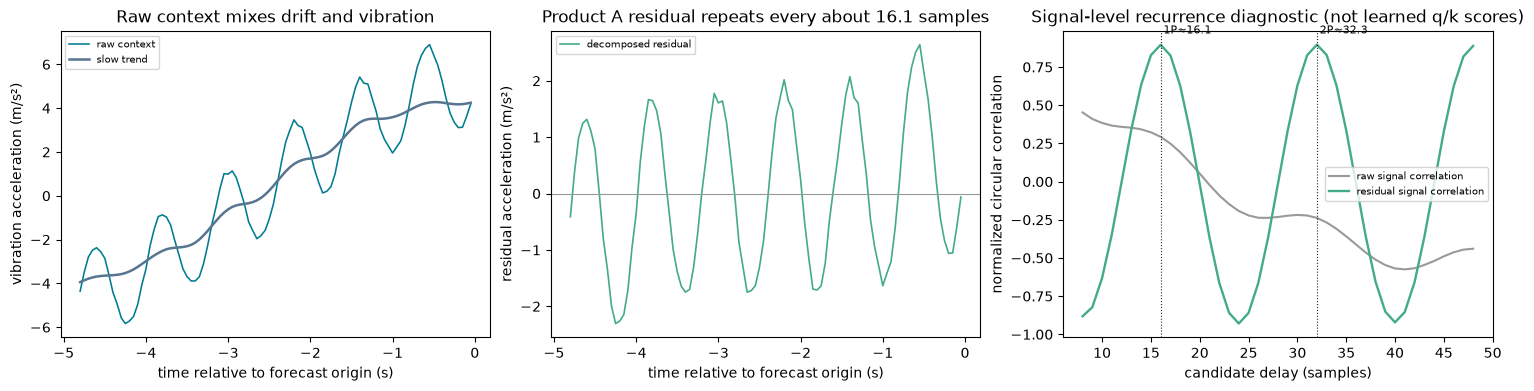

In [43]:
recurrence = figures.delay_recurrence(study)
report.publish("3.2", recurrence)


## 4. Compare Designs and Deploy

Nothing new to implement. Before running Output 4.1, write the prediction requested in
**Response 4** in at most two sentences. You now know both switches, so this part introduces the
supplied unified network. The four models are that one network with the two switches thrown
differently. The combined decomposed-delay configuration is called **Autoformer-inspired**.
They share width, depth, data order, optimizer schedule, and
checkpoint policy; they do **not** share parameter count or runtime, which Output 4.1 reports in
separate columns.

Produces **Outputs 4.1–4.3** → used in **Response 4**.

| Cell below | Output | Read it for |
| --- | --- | --- |
| fit the two remaining models; comparison table and contrasting forecast cases | 4.1 | Response 4 — write its prediction first |
| error along the 48-step horizon | 4.2 | Response 4 |
| selected models and their validation/test results | 4.3 | Response 4 |


Model assembly and gradient checks passed (4 setting(s): raw/attention, raw/delay, decomposed/attention, decomposed/delay).
Raw delay mixer: loaded raw-delay-mixer-full-data0-model0-3d386c30347d.pt (6000 steps, 10483.8s on cpu)
Autoformer-inspired: loaded autoformer-inspired-full-data0-model0-3a9bbdb01698.pt (6000 steps, 8129.6s on cpu)
Output 4.1


,model,established stations RMSE (m/s²),established stations MSE (m/s²)²,"established stations, Product A RMSE","established stations, Product B RMSE","established stations, Product C RMSE",held-out station 4 RMSE (m/s²),held-out station 4 MSE (m/s²)²,"held-out station 4, Product A RMSE","held-out station 4, Product B RMSE","held-out station 4, Product C RMSE",parameters,fit seconds
0,Raw Attention,0.431,0.186,0.388,0.482,0.418,0.612,0.374,0.647,0.580,0.607,368368,4990.703
1,Raw delay mixer,0.225,0.051,0.206,0.206,0.259,0.333,0.111,0.404,0.273,0.307,368370,10483.835
2,Attention + decomposition,0.296,0.087,0.264,0.335,0.283,0.430,0.185,0.359,0.488,0.434,373024,7021.893
3,Autoformer-inspired,0.199,0.040,0.225,0.188,0.183,0.240,0.057,0.269,0.220,0.227,373026,8129.553


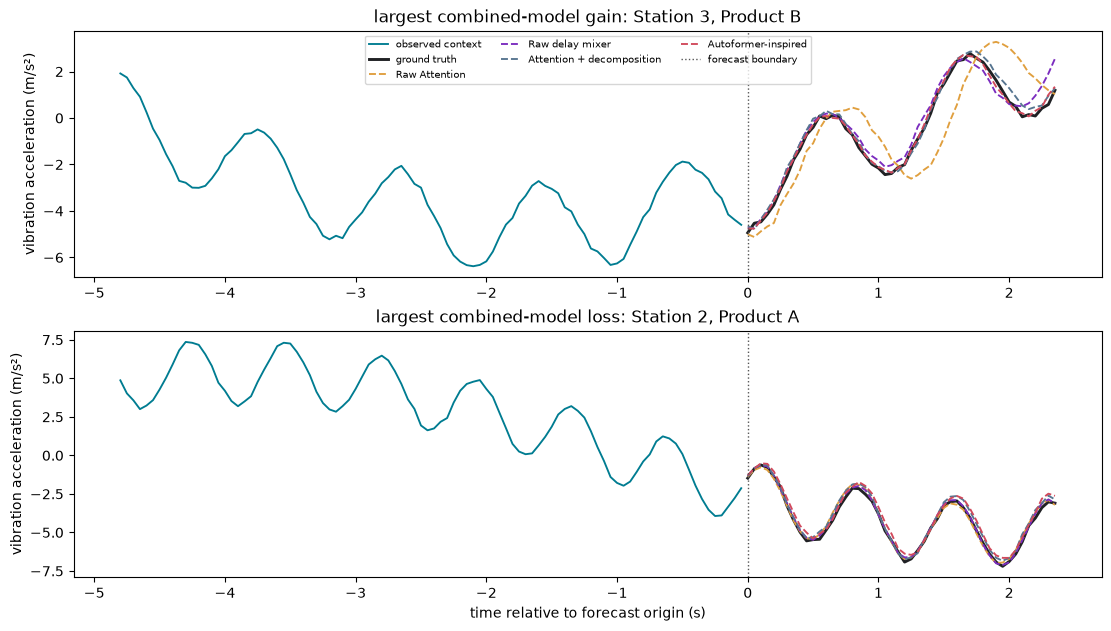

,case,station,product,model,window RMSE (m/s²)
0,largest combined-model gain,3,Product B,Raw Attention,1.325
1,largest combined-model gain,3,Product B,Raw delay mixer,0.437
2,largest combined-model gain,3,Product B,Attention + decomposition,0.242
3,largest combined-model gain,3,Product B,Autoformer-inspired,0.145
4,largest combined-model loss,2,Product A,Raw Attention,0.206
5,largest combined-model loss,2,Product A,Raw delay mixer,0.140
6,largest combined-model loss,2,Product A,Attention + decomposition,0.285
7,largest combined-model loss,2,Product A,Autoformer-inspired,0.375


In [44]:
# Supplied unified 2×2 design.
class IdentitySplit(nn.Module):
    def forward(self, x):
        return x, torch.zeros_like(x)

class EncoderBlock(nn.Module):
    def __init__(self, d, heads, mixing, kernel, decomposition_type,
                 delay_score_fn, aggregate_fn, dropout):
        super().__init__()
        self.mix = (DelayMixer(d, heads, delay_score_fn, aggregate_fn)
                    if mixing == "delay" else DenseAttention(d, heads))
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.feed_forward = nn.Sequential(
            nn.Linear(d, 2 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
        split = decomposition_type if decomposition_type is not None else lambda _: IdentitySplit()
        self.strip1, self.strip2 = split(kernel), split(kernel)

    def forward(self, x):                       # [B,L,d]
        x, _ = self.strip1(x + self.drop(self.mix(self.norm1(x))))
        x, _ = self.strip2(x + self.drop(self.feed_forward(self.norm2(x))))
        return x                               # [B,L,d]

class AutoformerInspiredForecaster(nn.Module):
    def __init__(self, context=96, horizon=48, channels=1, d=64, heads=4, layers=2,
                 mixing="attention", representation="raw", kernel=25, dropout=0.1,
                 decomposition_type=None, delay_score_fn=None, aggregate_fn=None):
        super().__init__()
        if representation not in {"raw", "decomposed"}:
            raise ValueError("representation must be 'raw' or 'decomposed'")
        self.split = (decomposition_type(kernel) if representation == "decomposed"
                      else IdentitySplit())
        self.trend_head = nn.Linear(context, horizon) if representation == "decomposed" else None
        self.embed = nn.Conv1d(channels, d, 3, padding=1, padding_mode="circular", bias=False)
        self.position = nn.Parameter(torch.randn(1, context, d) * 0.02)
        self.blocks = nn.ModuleList([EncoderBlock(
            d, heads, mixing, kernel, decomposition_type, delay_score_fn, aggregate_fn, dropout)
            for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.forecast_head = nn.Linear(context * d, horizon)

    def forward(self, context):                 # [B,L,1] -> [B,H]
        seasonal, trend = self.split(context)
        encoded = self.embed(seasonal.transpose(1, 2)).transpose(1, 2) + self.position
        for block in self.blocks:
            encoded = block(encoded)
        seasonal_forecast = self.forecast_head(self.norm(encoded).flatten(1))
        trend_forecast = 0 if self.trend_head is None else self.trend_head(trend.squeeze(-1))
        return seasonal_forecast + trend_forecast

    @property
    def attention_layers(self):
        return [block.mix for block in self.blocks if isinstance(block.mix, DenseAttention)]

    @property
    def delay_layers(self):
        return [block.mix for block in self.blocks if isinstance(block.mix, DelayMixer)]

assert design.check_assembly(AutoformerInspiredForecaster)
design.register_components(forecaster_type=AutoformerInspiredForecaster)
study.train("Raw delay mixer")
study.train("Autoformer-inspired")
cases = figures.contrasting_forecasts(study)
report.publish("4.1", report.comparison(study, [
    "Raw Attention", "Raw delay mixer", "Attention + decomposition", "Autoformer-inspired"]))
display(cases.round(3))


Output 4.2


,model,population,horizon,MSE,RMSE (m/s²)
0,Period-routed ridge,established,1,0.013,0.112
1,Period-routed ridge,established,2,0.011,0.107
2,Period-routed ridge,established,3,0.014,0.118
3,Period-routed ridge,established,4,0.014,0.118
4,Period-routed ridge,established,5,0.015,0.121
...,...,...,...,...,...
475,Autoformer-inspired,held-out,44,0.098,0.314
476,Autoformer-inspired,held-out,45,0.103,0.320
477,Autoformer-inspired,held-out,46,0.095,0.308
478,Autoformer-inspired,held-out,47,0.098,0.313


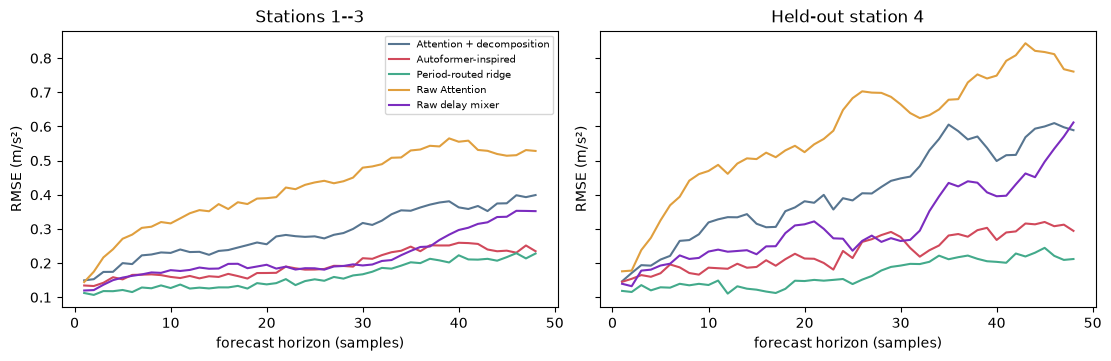

In [45]:
report.publish("4.2", figures.horizon_figure(study, [
    "Period-routed ridge", "Raw Attention", "Raw delay mixer",
    "Attention + decomposition", "Autoformer-inspired"]))


### Choose the deployment models (Response 4)

Choose one fitted model for the established stations and one for held-out station 4 using validation
MSE, physical-unit RMSE, parameter count, and fitting time,
then enter both model names below. Output 4.3 reports their validation and test results.

The compact validation-only decision summary below collects the error and cost quantities needed
for this choice. It is not another Output; Outputs 1.1 and 4.1–4.2 remain the detailed evidence.

| Cell below | Output | Read it for |
| --- | --- | --- |
| enter both choices | — | Response 4 |
| validation/test results for both choices | 4.3 | Response 4 |


In [46]:
# Validation-only decision summary.
display(report.deployment_summary(study).round(3))


,model,established validation RMSE (m/s²),established validation MSE (m/s²)²,held-out validation RMSE (m/s²),held-out validation MSE (m/s²)²,parameters,fit seconds
0,Shared ridge,0.767,0.588,0.876,0.767,4608,0.007
1,Sensor-specific ridge,0.768,0.590,NaN,NaN,13824,0.015
2,Period-routed ridge,0.166,0.028,0.173,0.030,59904,0.043
3,Raw Attention,0.431,0.186,0.612,0.374,368368,4990.703
4,Attention + decomposition,0.296,0.087,0.430,0.185,373024,7021.893
5,Raw delay mixer,0.225,0.051,0.333,0.111,368370,10483.835
6,Autoformer-inspired,0.199,0.040,0.240,0.057,373026,8129.553


In [48]:
choices = {
    "established": "Period-routed ridge",
    "held-out": "Period-routed ridge",
}
display(study.select_for_test(choices))


,population,model
0,established,Period-routed ridge
1,held-out,Period-routed ridge


In [49]:
report.publish("4.3", study.selected_test_table())


Output 4.3


,population,model,validation MSE,validation RMSE (m/s²),test MSE,test RMSE (m/s²)
0,established,Period-routed ridge,0.028,0.166,0.026,0.161
1,held-out,Period-routed ridge,0.030,0.173,0.033,0.183
